Imports:
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive

Leitura dos dados:
---

In [2]:
drive.mount('/content/drive')

caminho_discentes2021 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-discentes-2021-2025-03-31.csv'
caminho_discentes2022 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-discentes-2022-2025-03-31.csv'
caminho_discentes2023 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-discentes-2023-2025-03-31.csv'
caminho_discentes2024 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-discentes-2024-2025-12-01.csv'
caminhos_discentes = [
    caminho_discentes2021,
    caminho_discentes2022,
    caminho_discentes2023,
    caminho_discentes2024
]
lista_dataframes_discentes = [pd.read_csv(arq, encoding='latin1', sep=';', low_memory=False) for arq in caminhos_discentes]
df_discentes = pd.concat(lista_dataframes_discentes, ignore_index=True)

caminho_programas2021 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-curso-2021-2025-03-31.csv'
caminho_programas2022 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-curso-2022-2025-03-31.csv'
caminho_programas2023 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-curso-2023-2025-03-31.csv'
caminho_programas2024 = '/content/drive/MyDrive/MetodosQuantitativos/br-capes-colsucup-curso-2024-2025-12-01.csv'
caminhos_programas = [
    caminho_programas2021,
    caminho_programas2022,
    caminho_programas2023,
    caminho_programas2024,
]
lista_dataframes_programas = [pd.read_csv(arq, encoding='latin1', sep=';', low_memory=False) for arq in caminhos_programas]
df_programas = pd.concat(lista_dataframes_programas, ignore_index=True)

print(f"Total de linhas combinadas: {df_programas.shape[0]}")
df_programas.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de linhas combinadas: 28977


,AN_BASE,NM_GRANDE_AREA_CONHECIMENTO,NM_AREA_CONHECIMENTO,NM_SUBAREA_CONHECIMENTO,NM_ESPECIALIDADE,CD_AREA_AVALIACAO,NM_AREA_AVALIACAO,CD_ENTIDADE_CAPES,CD_ENTIDADE_EMEC,SG_ENTIDADE_ENSINO,...,NM_PROGRAMA_IES,CD_CURSO_PPG,NM_CURSO,NM_GRAU_CURSO,CD_CONCEITO_CURSO,AN_INICIO_PREVISTO,DS_SITUACAO_CURSO,DT_SITUACAO_CURSO,ID_ADD_FOTO_PROGRAMA_IES,ID_ADD_FOTO_PROGRAMA
0,2021,CIÊNCIAS DA SAÚDE,FARMÁCIA,NÃO SE APLICA,NÃO SE APLICA,19,FARMÁCIA,31010016,NI,FIOCRUZ,...,PESQUISA TRANSLACIONAL EM FÁRMACOS E MEDICAMENTOS,31010016152M8,PESQUISA TRANSLACIONAL EM FÁRMACOS E MEDICAMEN...,MESTRADO,4,2019,EM FUNCIONAMENTO,06AUG2019:00:00:00,250676,188434
1,2021,CIÊNCIAS DA SAÚDE,MEDICINA,CIRURGIA,NÃO SE APLICA,17,MEDICINA III,33004064,56,UNESP-BOT,...,CIRURGIA E MEDICINA TRANSLACIONAL,33004064006D9,CIRURGIA E MEDICINA TRANSLACIONAL,DOUTORADO,4,1975,EM FUNCIONAMENTO,18SEP2012:00:00:00,250726,188478
2,2021,CIÊNCIAS AGRÁRIAS,AGRONOMIA,NÃO SE APLICA,NÃO SE APLICA,42,CIÊNCIAS AGRÁRIAS I,33002037,55,USP/ESALQ,...,FISIOLOGIA BIOQUÍMICA DE PLANTAS,33002037016D5,FISIOLOGIA E BIOQUÍMICA DE PLANTAS,DOUTORADO,5,2003,EM FUNCIONAMENTO,18SEP2012:00:00:00,246364,184704
3,2021,MULTIDISCIPLINAR,MATERIAIS,NÃO SE APLICA,NÃO SE APLICA,47,MATERIAIS,33002045,55,USP/SC,...,CIÊNCIAS E ENGENHARIA DE MATERIAIS,33002045017D7,CIÊNCIAS E ENGENHARIA DE MATERIAIS,DOUTORADO,6,1993,EM FUNCIONAMENTO,18SEP2012:00:00:00,246860,185151
4,2021,CIÊNCIAS EXATAS E DA TERRA,GEOCIÊNCIAS,NÃO SE APLICA,NÃO SE APLICA,5,GEOCIÊNCIAS,33004129,56,UNESP-PP,...,CIÊNCIAS CARTOGRÁFICAS,33004129043D0,CIÊNCIAS CARTOGRÁFICAS,DOUTORADO,6,2000,EM FUNCIONAMENTO,18SEP2012:00:00:00,249652,187517


Funções de tratamento:
---

In [42]:
def simplificar_nivel(nivel):
    nivel_upper = str(nivel).upper()
    if 'DOUTORADO' in nivel_upper: return 'Doutorado'
    elif 'MESTRADO' in nivel_upper: return 'Mestrado'

def simplificar_situacao(sit):
    sit_upper = str(sit).upper()
    if 'TITULADO' in sit_upper or 'CONCLUÍDO' in sit_upper:
        return 'Titulado'
    elif 'DESLIGADO' in sit_upper or 'ABANDONO' in sit_upper:
        return 'Evasão/Desligado'
    elif 'MATRICULADO' in sit_upper or 'REGULAR' in sit_upper:
        return 'Regular/Ativo'
    else:
        return 'Regular/Ativo'

Questão 1:
---


--- PROPORÇÃO GERAL DE INSTITUIÇÕES NO BRASIL ---
Instituições PÚBLICA: 52.14%
Instituições PRIVADA: 47.86%


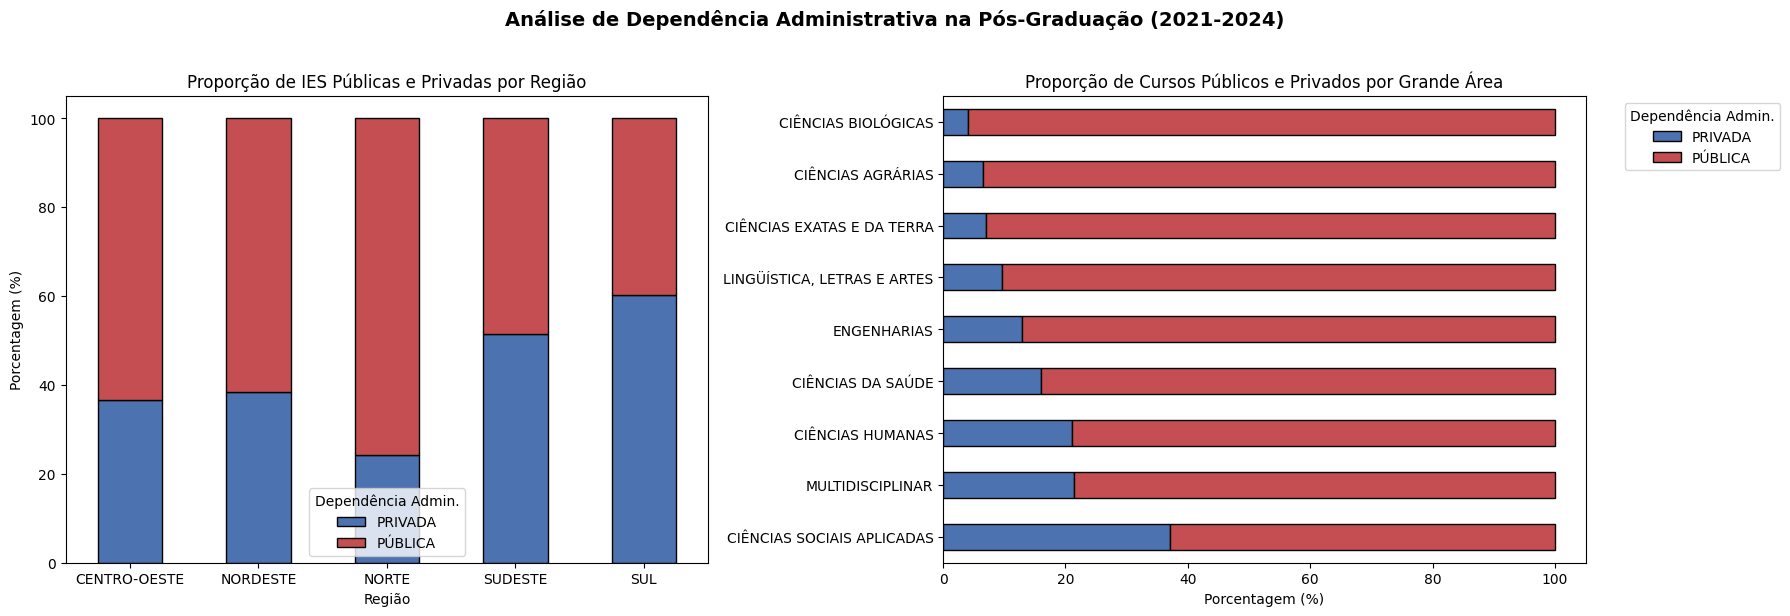

In [43]:
df_ies_unicas = df_programas.drop_duplicates(subset=['CD_ENTIDADE_CAPES']).copy()

proporcao_geral = df_ies_unicas['DS_DEPENDENCIA_ADMINISTRATIVA'].value_counts(normalize=True) * 100

print("\n--- PROPORÇÃO GERAL DE INSTITUIÇÕES NO BRASIL ---")
for tipo, prop in proporcao_geral.items():
    print(f"Instituições {tipo.strip().upper()}: {prop:.2f}%")


tabela_regiao = pd.crosstab(df_ies_unicas['NM_REGIAO'], df_ies_unicas['DS_DEPENDENCIA_ADMINISTRATIVA'], normalize='index') * 100

tabela_area = pd.crosstab(df_programas['NM_GRANDE_AREA_CONHECIMENTO'], df_programas['DS_DEPENDENCIA_ADMINISTRATIVA'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1
tabela_regiao.plot(kind='bar', stacked=True, ax=axes[0], color=['#4c72b0', '#c44e52'], edgecolor='black')
axes[0].set_title('Proporção de IES Públicas e Privadas por Região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Porcentagem (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Dependência Admin.')

# Gráfico 2
tabela_area.sort_values(by='PÚBLICA', ascending=True).plot(kind='barh', stacked=True, ax=axes[1], color=['#4c72b0', '#c44e52'], edgecolor='black')
axes[1].set_title('Proporção de Cursos Públicos e Privados por Grande Área')
axes[1].set_xlabel('Porcentagem (%)')
axes[1].set_ylabel('')
axes[1].legend(title='Dependência Admin.', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Análise de Dependência Administrativa na Pós-Graduação (2021-2024)', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

Questão 2:
---


--- TABELA RESUMO: CONCEITO CAPES vs. PERFIL DISCENTE POR NÍVEL ---


Qtd_Programas  Tempo_Medio_Meses  \
CD_CONCEITO_CURSO NIVEL_SIMPLIFICADO                                     
3                 Doutorado                      37              57.66   
                  Mestrado                     1023              29.18   
4                 Doutorado                    1017              52.22   
                  Mestrado                     1750              29.05   
5                 Doutorado                     979              53.25   
                  Mestrado                     1035              29.37   
6                 Doutorado                     413              54.99   
                  Mestrado                      407              30.00   
7                 Doutorado                     262              56.01   
                  Mestrado                      260              30.46   

                                      Taxa_Evasao_Pct  
CD_CONCEITO_CURSO NIVEL_SIMPLIFICADO                   
3                 Doutorado                      6.55  
                  Mestrado                       7.02  
4                 Doutorado                      2.59  
                  Mestrado                       5.06  
5                 Doutorado                      2.38  
                  Mestrado                       4.51  
6                 Doutorado                      2.50  
                  Mestrado                       4.12  
7                 Doutorado                      2.31  
                  Mestrado                       3.66

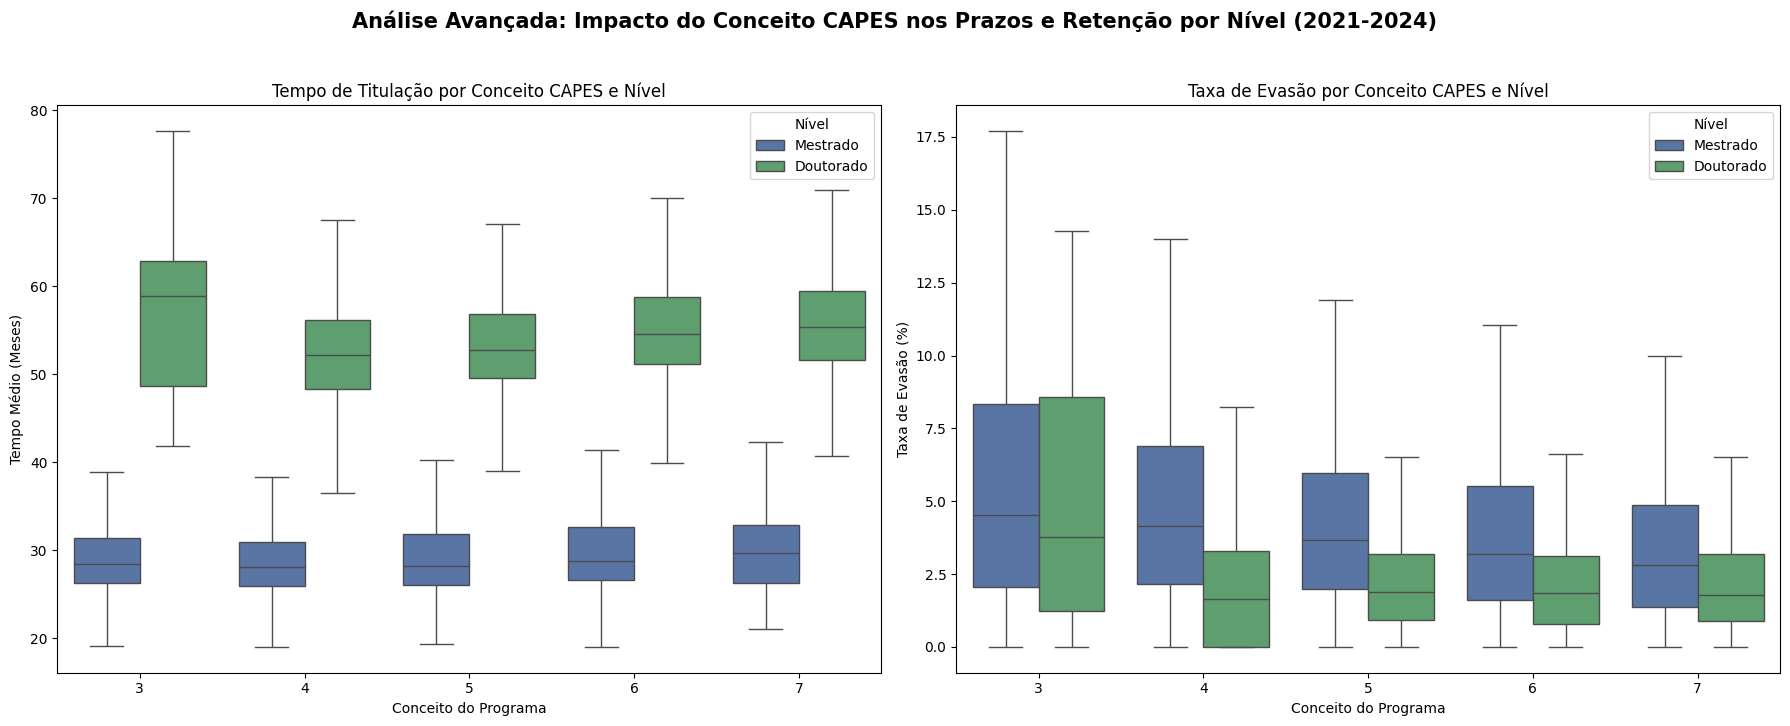

In [44]:
df_discentes['NIVEL_SIMPLIFICADO'] = df_discentes['DS_GRAU_ACADEMICO_DISCENTE'].apply(simplificar_nivel)
df_discentes_validos = df_discentes[df_discentes['NIVEL_SIMPLIFICADO'].isin(['Mestrado', 'Doutorado'])].copy()

evadidos = df_discentes_validos['NM_SITUACAO_DISCENTE'].str.upper().str.contains('DESLIGADO|ABANDONO', na=False)
df_discentes_validos['EM_EVASAO'] = np.where(evadidos, 1, 0)

df_titulados = df_discentes_validos[df_discentes_validos['QT_MES_TITULACAO'] > 0]
tempo_prog_nivel = df_titulados.groupby(['CD_PROGRAMA_IES', 'NIVEL_SIMPLIFICADO'])['QT_MES_TITULACAO'].mean().reset_index(name='TEMPO_MEDIO')
evasao_prog_nivel = df_discentes_validos.groupby(['CD_PROGRAMA_IES', 'NIVEL_SIMPLIFICADO'])['EM_EVASAO'].mean().reset_index(name='TAXA_EVASAO')
evasao_prog_nivel['TAXA_EVASAO'] *= 100
df_metricas_cruzadas = pd.merge(tempo_prog_nivel, evasao_prog_nivel, on=['CD_PROGRAMA_IES', 'NIVEL_SIMPLIFICADO'], how='outer')

df_conceito = df_programas[['CD_PROGRAMA_IES', 'CD_CONCEITO_CURSO']].drop_duplicates(subset=['CD_PROGRAMA_IES']).copy()
df_conceito['CD_CONCEITO_CURSO'] = df_conceito['CD_CONCEITO_CURSO'].astype(str)

df_final_q2 = pd.merge(df_metricas_cruzadas, df_conceito, on='CD_PROGRAMA_IES', how='inner')
df_final_q2 = df_final_q2[df_final_q2['CD_CONCEITO_CURSO'].isin(['3', '4', '5', '6', '7'])].sort_values('CD_CONCEITO_CURSO')


tabela_resumo_cruzada = df_final_q2.groupby(['CD_CONCEITO_CURSO', 'NIVEL_SIMPLIFICADO']).agg(
    Qtd_Programas=('CD_PROGRAMA_IES', 'count'),
    Tempo_Medio_Meses=('TEMPO_MEDIO', 'mean'),
    Taxa_Evasao_Pct=('TAXA_EVASAO', 'mean')
)


print("\n--- TABELA RESUMO: CONCEITO CAPES vs. PERFIL DISCENTE POR NÍVEL ---")
display(tabela_resumo_cruzada.round(2))
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

paleta_niveis = {'Mestrado': '#4c72b0', 'Doutorado': '#55a868'}

# Gráfico 1
sns.boxplot(data=df_final_q2, x='CD_CONCEITO_CURSO', y='TEMPO_MEDIO', hue='NIVEL_SIMPLIFICADO',
            ax=axes[0], palette=paleta_niveis, showfliers=False)
axes[0].set_title('Tempo de Titulação por Conceito CAPES e Nível')
axes[0].set_xlabel('Conceito do Programa')
axes[0].set_ylabel('Tempo Médio (Meses)')
axes[0].legend(title='Nível')

# Gráfico 2
sns.boxplot(data=df_final_q2, x='CD_CONCEITO_CURSO', y='TAXA_EVASAO', hue='NIVEL_SIMPLIFICADO',
            ax=axes[1], palette=paleta_niveis, showfliers=False)
axes[1].set_title('Taxa de Evasão por Conceito CAPES e Nível')
axes[1].set_xlabel('Conceito do Programa')
axes[1].set_ylabel('Taxa de Evasão (%)')
axes[1].legend(title='Nível')

plt.suptitle('Análise Avançada: Impacto do Conceito CAPES nos Prazos e Retenção por Nível (2021-2024)',
             fontsize=15, weight='bold', y=1.03)
plt.tight_layout()
plt.show()

Questão 3:
---


--- IDADE MÉDIA POR MODALIDADE E NÍVEL ---


NIVEL_SIMPLIFICADO,Doutorado,Mestrado
NM_MODALIDADE_PROGRAMA,,
ACADÊMICO,36.52,32.31
PROFISSIONAL,42.98,38.66



--- TEMPO MÉDIO DE TITULAÇÃO (MESES) ---


NIVEL_SIMPLIFICADO,Doutorado,Mestrado
NM_MODALIDADE_PROGRAMA,,
ACADÊMICO,53.71,29.11
PROFISSIONAL,45.17,29.10


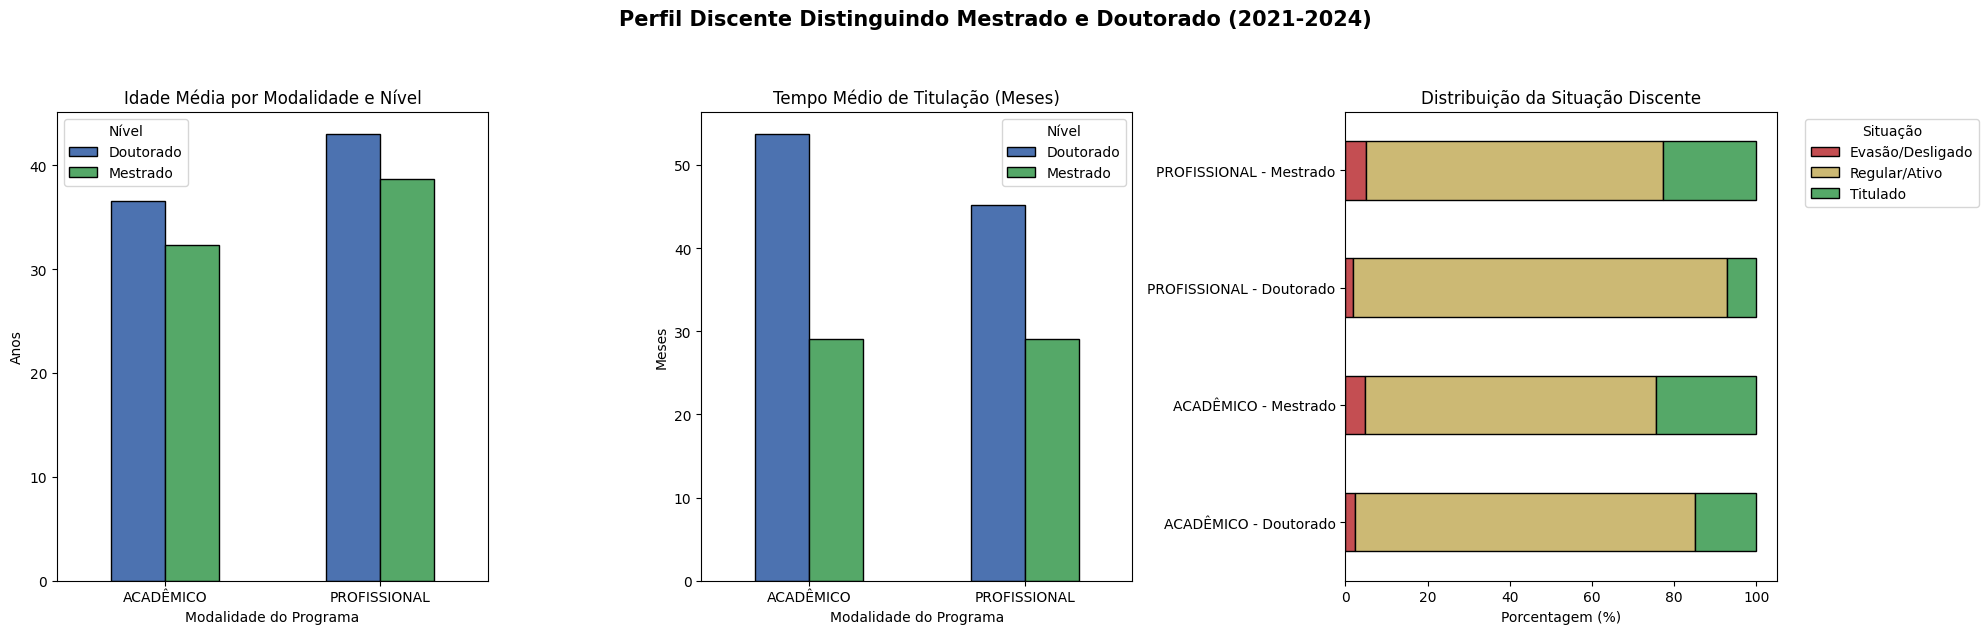

In [45]:
df_discentes['NIVEL_SIMPLIFICADO'] = df_discentes['DS_GRAU_ACADEMICO_DISCENTE'].apply(simplificar_nivel)
df_discentes['SITUACAO_SIMPLIFICADA'] = df_discentes['NM_SITUACAO_DISCENTE'].apply(simplificar_situacao)

df_validos = df_discentes[df_discentes['NIVEL_SIMPLIFICADO'].isin(['Mestrado', 'Doutorado'])].copy()

if 'NR_IDADE_DISCENTE' not in df_validos.columns:
    df_validos['IDADE_ESTIMADA'] = df_validos['AN_BASE'] - df_validos['AN_NASCIMENTO_DISCENTE']
else:
    df_validos['IDADE_ESTIMADA'] = df_validos['NR_IDADE_DISCENTE']

df_idade_ok = df_validos[(df_validos['IDADE_ESTIMADA'] > 18) & (df_validos['IDADE_ESTIMADA'] < 90)]
idade_cruzada = df_idade_ok.groupby(['NM_MODALIDADE_PROGRAMA', 'NIVEL_SIMPLIFICADO'])['IDADE_ESTIMADA'].mean().unstack()

df_titulados = df_validos[df_validos['QT_MES_TITULACAO'] > 0]
tempo_cruzado = df_titulados.groupby(['NM_MODALIDADE_PROGRAMA', 'NIVEL_SIMPLIFICADO'])['QT_MES_TITULACAO'].mean().unstack()

df_validos['MODALIDADE_NIVEL'] = df_validos['NM_MODALIDADE_PROGRAMA'] + " - " + df_validos['NIVEL_SIMPLIFICADO']
tabela_situacao_cruzada = pd.crosstab(df_validos['MODALIDADE_NIVEL'], df_validos['SITUACAO_SIMPLIFICADA'], normalize='index') * 100

print("\n--- IDADE MÉDIA POR MODALIDADE E NÍVEL ---")
display(idade_cruzada.round(2))

print("\n--- TEMPO MÉDIO DE TITULAÇÃO (MESES) ---")
display(tempo_cruzado.round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1
idade_cruzada.plot(kind='bar', ax=axes[0], color=['#4c72b0', '#55a868'], edgecolor='black')
axes[0].set_title('Idade Média por Modalidade e Nível')
axes[0].set_ylabel('Anos')
axes[0].set_xlabel('Modalidade do Programa')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Nível')

# Gráfico 2
tempo_cruzado.plot(kind='bar', ax=axes[1], color=['#4c72b0', '#55a868'], edgecolor='black')
axes[1].set_title('Tempo Médio de Titulação (Meses)')
axes[1].set_ylabel('Meses')
axes[1].set_xlabel('Modalidade do Programa')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Nível')

# Gráfico 3
tabela_situacao_cruzada.plot(kind='barh', stacked=True, ax=axes[2], color=['#c44e52', '#ccb974', '#55a868', '#8172b3'], edgecolor='black')
axes[2].set_title('Distribuição da Situação Discente')
axes[2].set_xlabel('Porcentagem (%)')
axes[2].set_ylabel('')
axes[2].legend(title='Situação', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Perfil Discente Distinguindo Mestrado e Doutorado (2021-2024)', fontsize=15, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

Questão 4:
---


--- TABELA DE EVOLUÇÃO POR REGIÃO E ANO ---


,NM_REGIAO,AN_BASE,Total_Programas,Total_Cursos,Total_Discentes
0,CENTRO-OESTE,2021,422,605,33246
1,CENTRO-OESTE,2022,396,576,33804
2,CENTRO-OESTE,2023,407,604,34809
3,CENTRO-OESTE,2024,405,634,35523
4,NORDESTE,2021,977,1378,82376
5,NORDESTE,2022,958,1357,84803
6,NORDESTE,2023,975,1420,87836
7,NORDESTE,2024,962,1466,90103
8,NORTE,2021,308,409,23608
9,NORTE,2022,289,387,24582


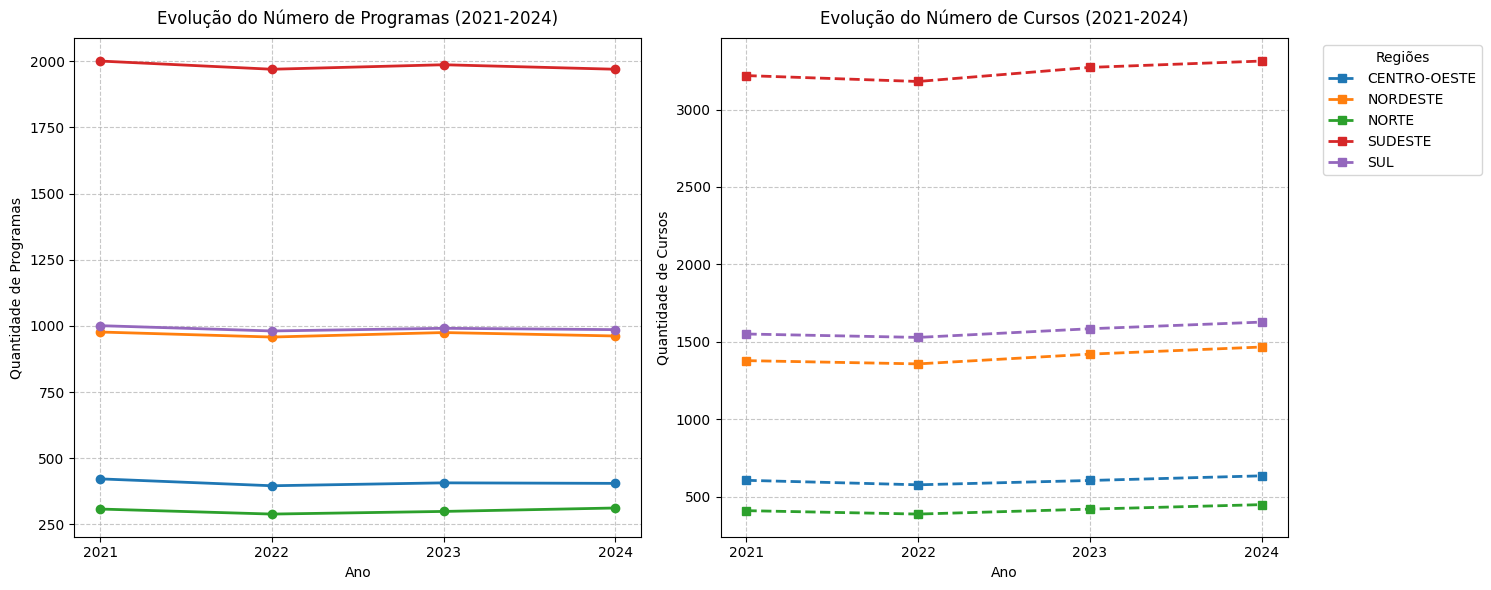

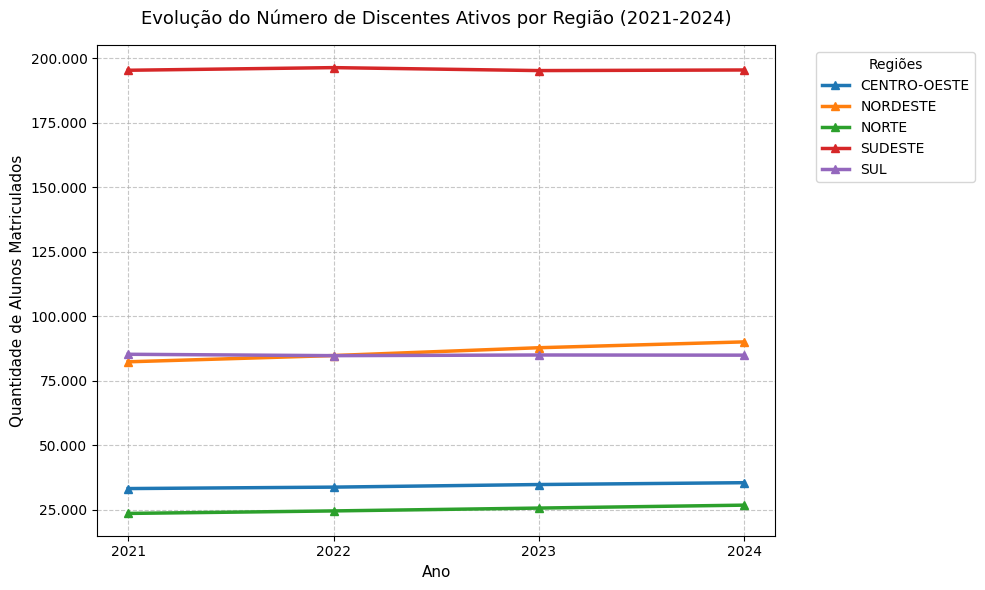

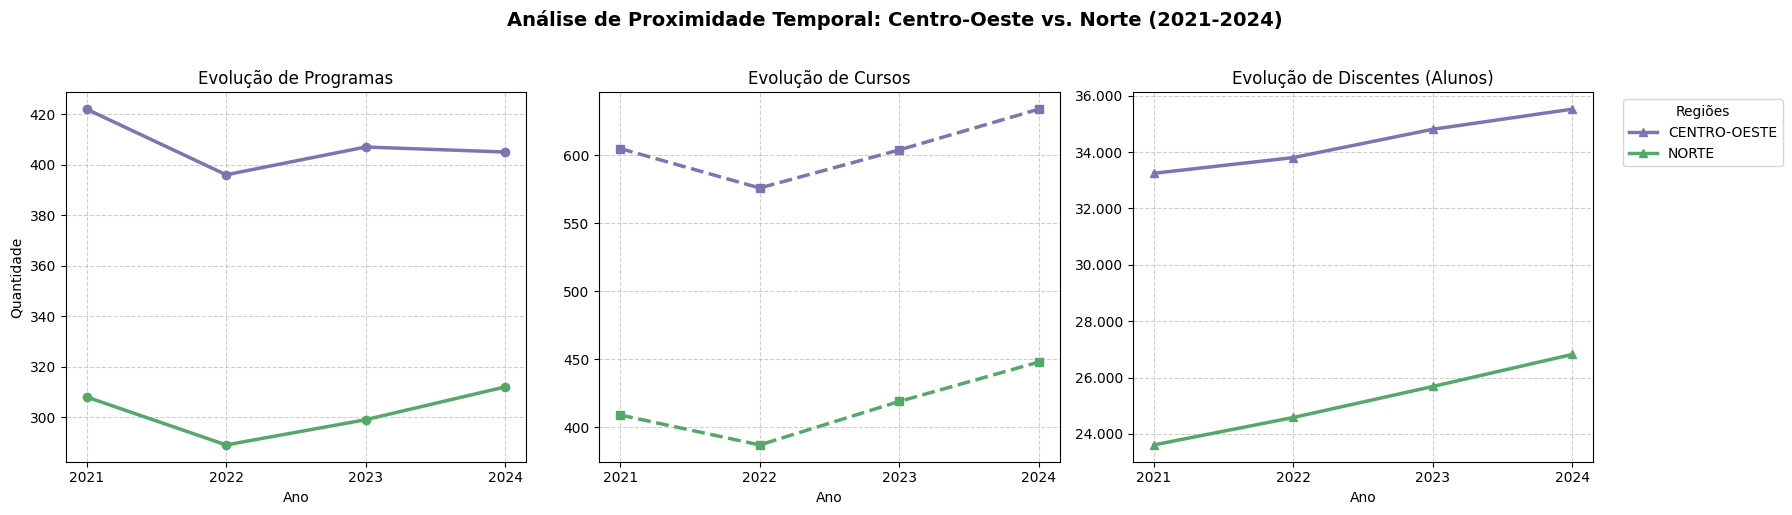

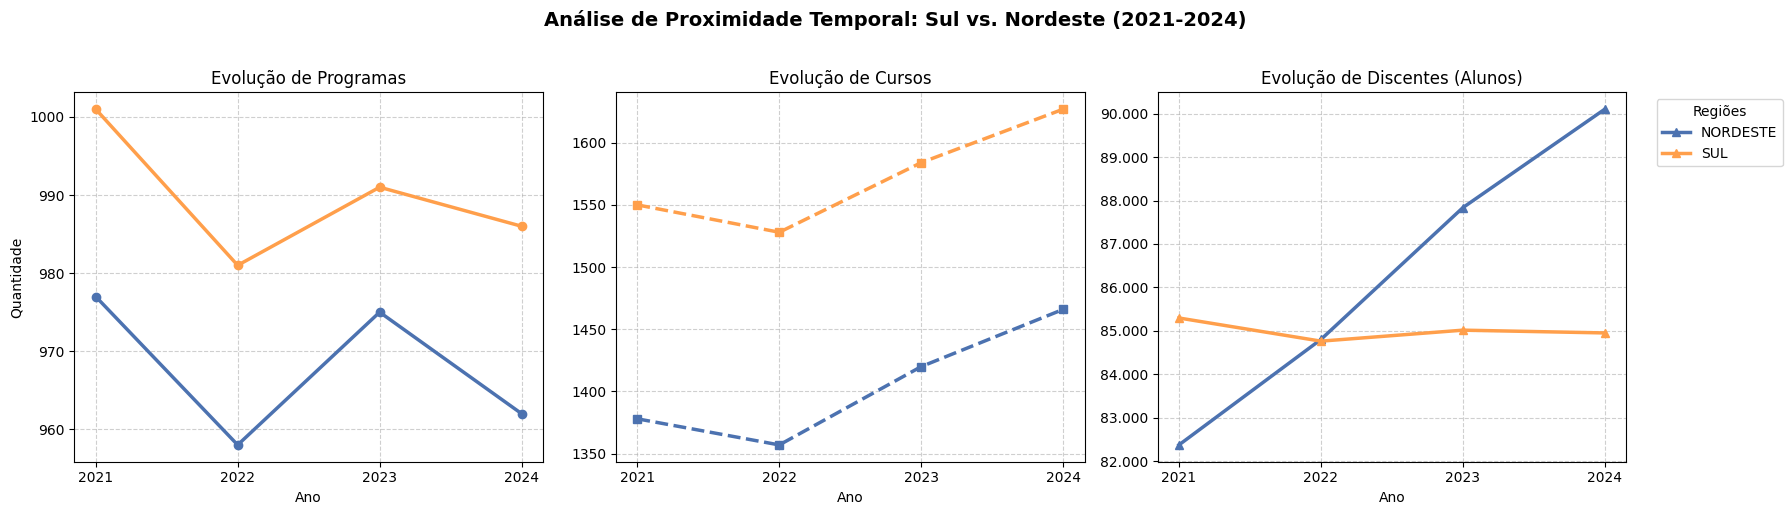

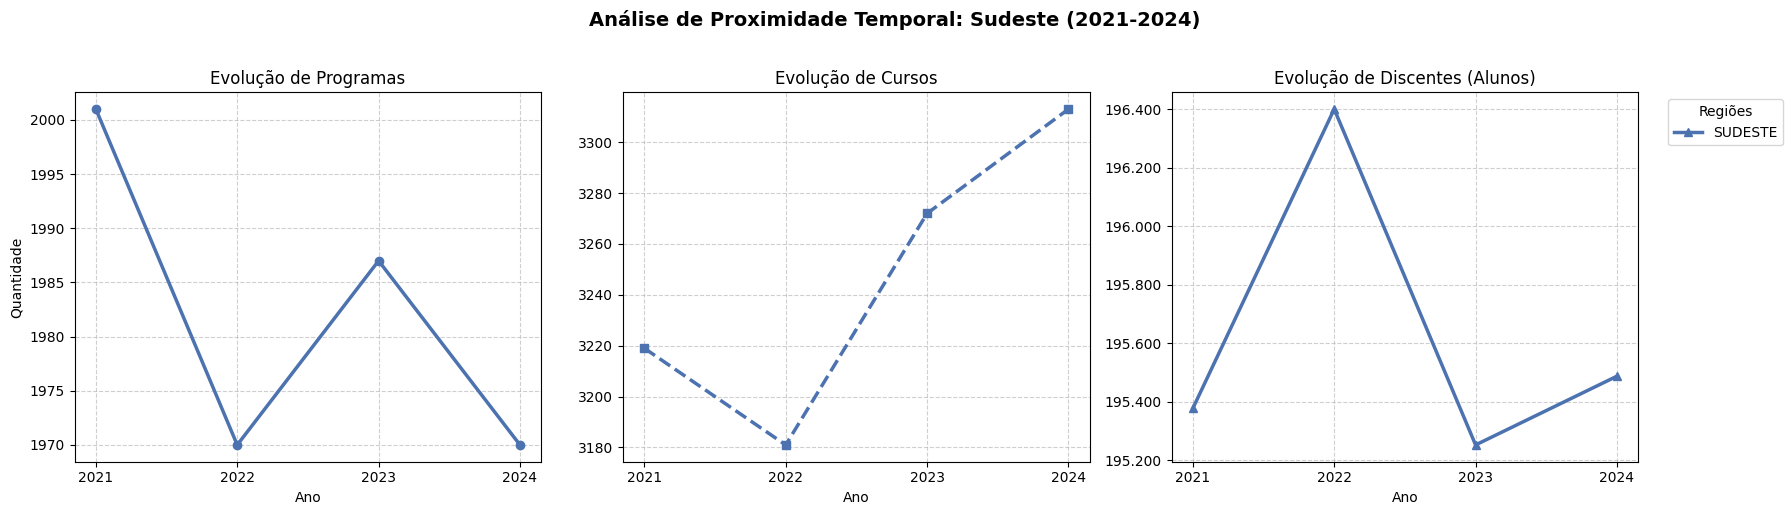

In [46]:
df_programas['AN_BASE'] = df_programas['AN_BASE'].astype(int)
df_discentes['AN_BASE'] = df_discentes['AN_BASE'].astype(int)

evolucao_prog_curso = df_programas.groupby(['NM_REGIAO', 'AN_BASE']).agg(
    Total_Programas=('CD_PROGRAMA_IES', 'nunique'),
    Total_Cursos=('CD_CURSO_PPG', 'nunique')
).reset_index()

evolucao_discentes = df_discentes.groupby(['NM_REGIAO', 'AN_BASE']).agg(
    Total_Discentes=('AN_BASE', 'size')
).reset_index()

df_evolucao_final = pd.merge(evolucao_prog_curso, evolucao_discentes, on=['NM_REGIAO', 'AN_BASE'])

print("\n--- TABELA DE EVOLUÇÃO POR REGIÃO E ANO ---")
display(df_evolucao_final)

fig1, axes1 = plt.subplots(1, 2, figsize=(15, 6))
regioes = df_evolucao_final['NM_REGIAO'].unique()

# Gráfico 1
for regiao in regioes:
    dados_regiao = df_evolucao_final[df_evolucao_final['NM_REGIAO'] == regiao]
    axes1[0].plot(dados_regiao['AN_BASE'], dados_regiao['Total_Programas'], marker='o', linewidth=2, label=regiao)
axes1[0].set_title('Evolução do Número de Programas (2021-2024)', fontsize=12, pad=10)
axes1[0].set_xlabel('Ano')
axes1[0].set_ylabel('Quantidade de Programas')
axes1[0].set_xticks([2021, 2022, 2023, 2024])
axes1[0].grid(True, linestyle='--', alpha=0.7)

# Gráfico 2
for regiao in regioes:
    dados_regiao = df_evolucao_final[df_evolucao_final['NM_REGIAO'] == regiao]
    axes1[1].plot(dados_regiao['AN_BASE'], dados_regiao['Total_Cursos'], marker='s', linestyle='--', linewidth=2, label=regiao)
axes1[1].set_title('Evolução do Número de Cursos (2021-2024)', fontsize=12, pad=10)
axes1[1].set_xlabel('Ano')
axes1[1].set_ylabel('Quantidade de Cursos')
axes1[1].set_xticks([2021, 2022, 2023, 2024])
axes1[1].grid(True, linestyle='--', alpha=0.7)

axes1[1].legend(title='Regiões', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Gráfico 3
plt.figure(figsize=(10, 6))

for regiao in regioes:
    dados_regiao = df_evolucao_final[df_evolucao_final['NM_REGIAO'] == regiao]
    plt.plot(dados_regiao['AN_BASE'], dados_regiao['Total_Discentes'], marker='^', linewidth=2.5, label=regiao)

plt.title('Evolução do Número de Discentes Ativos por Região (2021-2024)', fontsize=13, pad=15)
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Quantidade de Alunos Matriculados', fontsize=11)
plt.xticks([2021, 2022, 2023, 2024])
plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(",", ".")))

plt.legend(title='Regiões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

df_par1 = df_evolucao_final[df_evolucao_final['NM_REGIAO'].isin(['CENTRO-OESTE', 'NORTE'])]
df_par2 = df_evolucao_final[df_evolucao_final['NM_REGIAO'].isin(['SUL', 'NORDESTE'])]
df_sudeste = df_evolucao_final[df_evolucao_final['NM_REGIAO'].isin(['SUDESTE'])]

def plotar_comparativo_par(df_par, nome_par, cores):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    regioes_par = df_par['NM_REGIAO'].unique()

    for i, regiao in enumerate(regioes_par):
        dados = df_par[df_par['NM_REGIAO'] == regiao]
        axes[0].plot(dados['AN_BASE'], dados['Total_Programas'], marker='o', linewidth=2.5, color=cores[i], label=regiao)
    axes[0].set_title('Evolução de Programas')
    axes[0].set_ylabel('Quantidade')

    for i, regiao in enumerate(regioes_par):
        dados = df_par[df_par['NM_REGIAO'] == regiao]
        axes[1].plot(dados['AN_BASE'], dados['Total_Cursos'], marker='s', linestyle='--', linewidth=2.5, color=cores[i], label=regiao)
    axes[1].set_title('Evolução de Cursos')

    for i, regiao in enumerate(regioes_par):
        dados = df_par[df_par['NM_REGIAO'] == regiao]
        axes[2].plot(dados['AN_BASE'], dados['Total_Discentes'], marker='^', linewidth=2.5, color=cores[i], label=regiao)
    axes[2].set_title('Evolução de Discentes (Alunos)')
    axes[2].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(",", ".")))


    for ax in axes:
        ax.set_xlabel('Ano')
        ax.set_xticks([2021, 2022, 2023, 2024])
        ax.grid(True, linestyle='--', alpha=0.6)

    axes[2].legend(title='Regiões', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f'Análise de Proximidade Temporal: {nome_par} (2021-2024)', fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Gráfico 4
plotar_comparativo_par(df_par1, "Centro-Oeste vs. Norte", cores=['#8172b3', '#55a868'])

# Gráfico 5
plotar_comparativo_par(df_par2, "Sul vs. Nordeste", cores=['#4c72b0', '#ff9f4b'])

# Gráfico 6
plotar_comparativo_par(df_sudeste, "Sudeste", cores=['#4c72b0', '#ff9f4b'])

Questão 5:
---

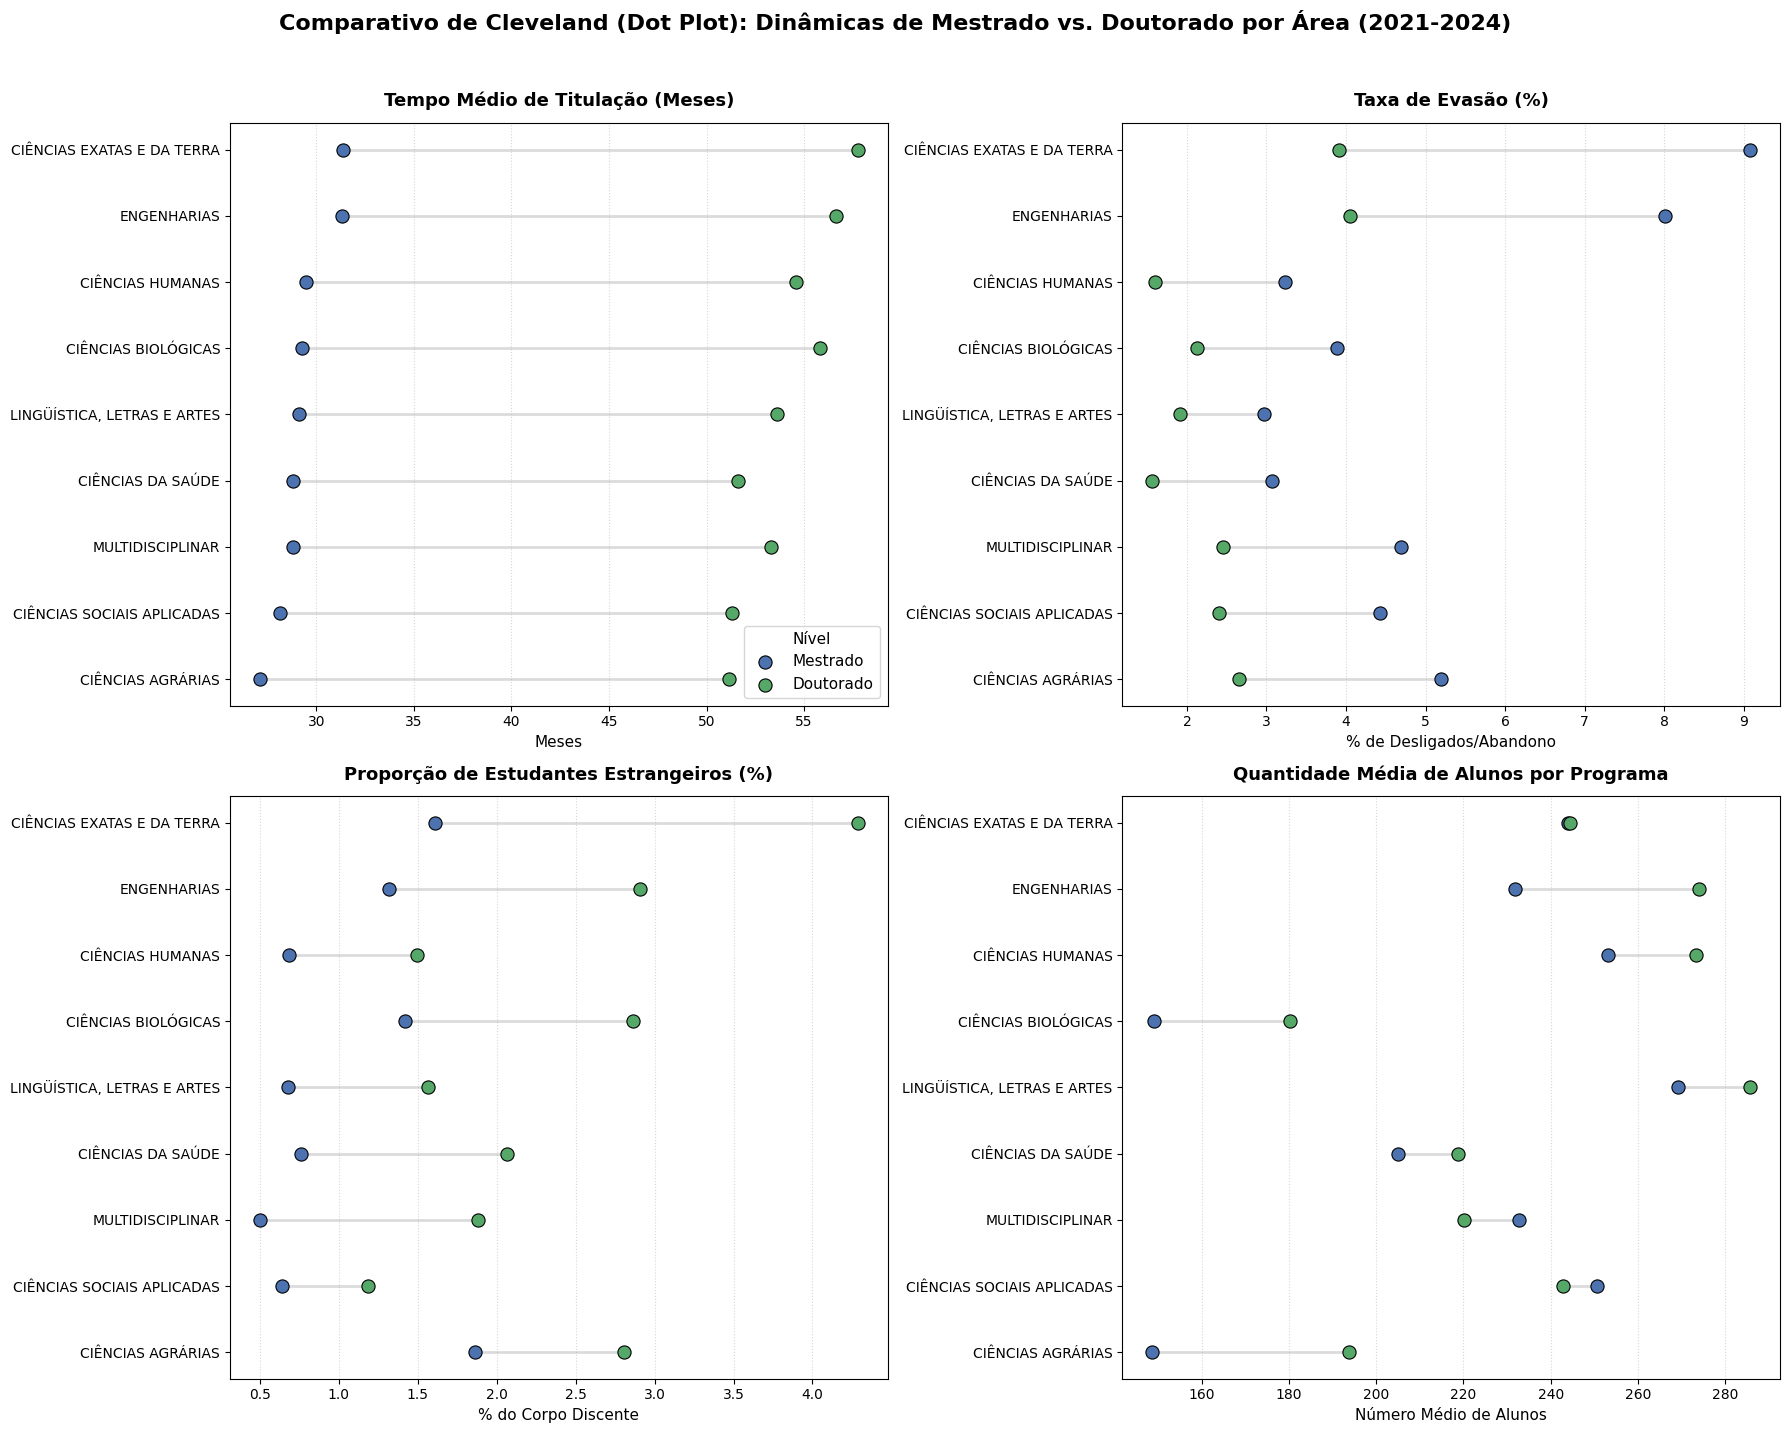

In [47]:
df_discentes['NIVEL_SIMPLIFICADO'] = df_discentes['DS_GRAU_ACADEMICO_DISCENTE'].apply(simplificar_nivel)

df_analise = df_discentes[df_discentes['NIVEL_SIMPLIFICADO'].isin(['Mestrado', 'Doutorado'])].copy()

df_titulados = df_analise[df_analise['QT_MES_TITULACAO'] > 0]
tempo_tit = df_titulados.groupby(['NM_GRANDE_AREA_CONHECIMENTO', 'NIVEL_SIMPLIFICADO'])['QT_MES_TITULACAO'].mean().unstack()

evadidos = df_analise['NM_SITUACAO_DISCENTE'].str.upper().str.contains('DESLIGADO|ABANDONO', na=False)
df_analise['EM_EVASAO'] = np.where(evadidos, 1, 0)
taxa_evasao = df_analise.groupby(['NM_GRANDE_AREA_CONHECIMENTO', 'NIVEL_SIMPLIFICADO'])['EM_EVASAO'].mean().unstack() * 100

estrangeiros = ~df_analise['NM_PAIS_NACIONALIDADE_DISCENTE'].str.upper().str.contains('BRASIL', na=False)
df_analise['ESTRANGEIRO'] = np.where(estrangeiros, 1, 0)
prop_estrangeiros = df_analise.groupby(['NM_GRANDE_AREA_CONHECIMENTO', 'NIVEL_SIMPLIFICADO'])['ESTRANGEIRO'].mean().unstack() * 100

alunos_prog_nivel = df_analise.groupby(['NM_GRANDE_AREA_CONHECIMENTO', 'CD_PROGRAMA_IES', 'NIVEL_SIMPLIFICADO']).size().reset_index(name='QTD')
tamanho_prog = alunos_prog_nivel.groupby(['NM_GRANDE_AREA_CONHECIMENTO', 'NIVEL_SIMPLIFICADO'])['QTD'].mean().unstack()

ordem_areas = tempo_tit['Mestrado'].sort_values().index

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

def desenhar_dot_plot(df_metrica, titulo, xlabel, ax, exibir_legenda=False):
    df_ordenado = df_metrica.loc[ordem_areas]

    ax.hlines(y=df_ordenado.index, xmin=df_ordenado['Mestrado'], xmax=df_ordenado['Doutorado'],
              color='#cccccc', alpha=0.7, linewidth=2, zorder=1)

    ax.scatter(df_ordenado['Mestrado'], df_ordenado.index, color='#4c72b0',
               label='Mestrado', s=90, edgecolor='black', linewidth=0.8, zorder=3)

    if 'Doutorado' in df_ordenado.columns:
        ax.scatter(df_ordenado['Doutorado'], df_ordenado.index, color='#55a868',
                   label='Doutorado', s=90, edgecolor='black', linewidth=0.8, zorder=3)

    ax.set_title(titulo, fontsize=13, pad=12, weight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('')
    ax.grid(True, linestyle=':', alpha=0.5, axis='x')

    if exibir_legenda:
        ax.legend(title='Nível', fontsize=11, title_fontsize=11, loc='best')

desenhar_dot_plot(tempo_tit, 'Tempo Médio de Titulação (Meses)', 'Meses', axes[0,0], exibir_legenda=True)
desenhar_dot_plot(taxa_evasao, 'Taxa de Evasão (%)', '% de Desligados/Abandono', axes[0,1])
desenhar_dot_plot(prop_estrangeiros, 'Proporção de Estudantes Estrangeiros (%)', '% do Corpo Discente', axes[1,0])
desenhar_dot_plot(tamanho_prog, 'Quantidade Média de Alunos por Programa', 'Número Médio de Alunos', axes[1,1])

plt.suptitle('Comparativo de Cleveland (Dot Plot): Dinâmicas de Mestrado vs. Doutorado por Área (2021-2024)',
             fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

Rascunhos:
---

In [48]:
valores_unicos = df_discentes['NM_SITUACAO_DISCENTE'].unique()
print(valores_unicos)
len(valores_unicos)



['MATRICULADO' 'TITULADO' 'DESLIGADO' 'ABANDONOU'
 'MUDANÇA DE NÍVEL SEM DEFESA']


5